In [5]:
from typing import TypedDict

from langgraph.graph import StateGraph, END

from langchain_groq import ChatGroq

from pydantic import BaseModel, Field

import os
import json
import subprocess

In [6]:
import os

os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0
)

In [7]:
from pydantic import BaseModel


class ArchitecturePlan(BaseModel):

    project_name: str

    frontend_files: list[str]

    backend_files:list[str]

    database_type: str

architecture_llm=llm.with_structured_output(ArchitecturePlan)

In [8]:
def architecture_agent(state):

    prompt = f"""
You are a software architect.

User Request:
{state["user_request"]}

Create a SIMPLE project structure.

Rules Backend:

- Include main.py
- Include utils.py
- Include db.py
- Include routes.py
- Include requirements.txt
- Keep file count minimal
- Avoid overengineering
- Beginner friendly

Rules Frontend:
- Include index.html
- Include styles.css
- Include app.js
- Avoid overengineering
- Beginner friendly


Return:

project_name
frontend_files
backend_files
database_type:

NOTE:
- Return frontend files like "frontend/index.html", "frontend/styles.css", "frontend/app.js"
- Return backend files like "backend/main.py", "backend/utils.py", "backend/db.py", "backend/routes.py", "backend/requirements.txt"
"""

    result = architecture_llm.invoke(
        prompt
    )

    state["project_name"] = (
        result.project_name
    )

    state["frontend_files"] = (
        result.frontend_files
    )

    state["backend_files"] = (
        result.backend_files
    )

    state["database_type"] = (
        result.database_type
    )
    state["all_project_files"] = (
        result.frontend_files + result.backend_files
    )

    print("\nPROJECT:")
    print(result.project_name)

    print("\nFRONTEND FILES:")
    print(result.frontend_files)

    print("\nBACKEND FILES:")
    print(result.backend_files)

    print("\nDATABASE TYPE:")
    print(result.database_type)

    return state

In [9]:
state = {

    # User Request
    "user_request":
    "Create a simple calculator app using flask and HTML,CSS,JS and mongodb database",

    # Architecture
    "project_name": "",

    "frontend_files": [],

    "backend_files": [],

    "support_files": [],

    "database_type": "",
    "workspace": r"C:\Users\ASUS\Desktop\Coding agent\workspace",
    "database_rule": "",
    # Project Specification
    "project_spec": "",

    "project_dependencies": [],

    "environment_variables": [],

    "api_endpoints": [],
    ## File Responsibilities

    "file_contracts": {},
    "generation_order": [],
    "backend_generation_order": [],
    "frontend_generation_order": [],
    "dependency_validation_logs": [],
    "backend_current_index": 0,

    "frontend_current_index": 0,

    # Generation

    "backend_generated": False,

    "frontend_generated": False,

    "api_contract": {},
    
    "current_file_index": 0,

    "all_project_files": [],

    "generated_code": {},

    # Validation
    "validation_logs": [],

    # Dependencies
    "installed_dependencies": [],

    # Execution
    "backend_pid": None,

    "frontend_pid": None,

    "backend_url": None,

    "frontend_url": None,

    "execution_logs": [],
    "api_test_results": [],


    "created_resource_id": None,

    "api_test_logs": [],

    "browser_test_logs": [],

    "test_results": {},

    "run_success": False,

    "api_tests_passed": False,

    "browser_tests_passed": False,

    # Error Handling
    "errors": [],

    "has_error": False,

    # Debug Loop
    "retry_count": 0,

    "max_retries": 3,

    # Final Output
    "final_output": ""
}

In [10]:
state=architecture_agent(state)
state


PROJECT:
Simple Calculator App

FRONTEND FILES:
['frontend/index.html', 'frontend/styles.css', 'frontend/app.js']

BACKEND FILES:
['backend/main.py', 'backend/utils.py', 'backend/db.py', 'backend/routes.py', 'backend/requirements.txt']

DATABASE TYPE:
mongodb


{'user_request': 'Create a simple calculator app using flask and HTML,CSS,JS and mongodb database',
 'project_name': 'Simple Calculator App',
 'frontend_files': ['frontend/index.html',
  'frontend/styles.css',
  'frontend/app.js'],
 'backend_files': ['backend/main.py',
  'backend/utils.py',
  'backend/db.py',
  'backend/routes.py',
  'backend/requirements.txt'],
 'support_files': [],
 'database_type': 'mongodb',
 'workspace': 'C:\\Users\\ASUS\\Desktop\\Coding agent\\workspace',
 'database_rule': '',
 'project_spec': '',
 'project_dependencies': [],
 'environment_variables': [],
 'api_endpoints': [],
 'file_contracts': {},
 'generation_order': [],
 'backend_generation_order': [],
 'frontend_generation_order': [],
 'dependency_validation_logs': [],
 'backend_current_index': 0,
 'frontend_current_index': 0,
 'backend_generated': False,
 'frontend_generated': False,
 'api_contract': {},
 'current_file_index': 0,
 'all_project_files': ['frontend/index.html',
  'frontend/styles.css',
  'fron

In [11]:
from pydantic import BaseModel


class ApiEndpoint(BaseModel):

    method: str

    endpoint: str


class ProjectSpecOutput(BaseModel):

    application_type: str

    architecture_style: str

    frontend_stack: list[str] 

    backend_stack: list[str]

    database: str

    folder_structure: list[str]

    data_models: list[str]

    api_endpoints: list[ApiEndpoint] | None=None

    dependencies: list[str]

    environment_variables: list[str]

    coding_rules: list[str]

    specification: str

spec_llm=llm.with_structured_output(ProjectSpecOutput)

In [12]:
def project_spec_agent(state):

    prompt = f"""
You are a senior software architect.

User Request:
{state["user_request"]}

Frontend Files:
{state["frontend_files"]}

Backend Files:
{state["backend_files"]}

Database:
{state["database_type"]}

Create a COMPLETE project specification.

The specification MUST contain the following sections.

Application Type:
Describe the application.

Architecture Style:
Monolithic, Full Stack, REST API, etc.

Frontend Stack:
HTML
CSS
JavaScript

Backend Stack:
Flask

Database:
{state["database_type"]}

Folder Structure:
Show frontend and backend folders.

Data Models:
Define all models/collections.

API Endpoints:
List every endpoint.
API endpoint includes method

Frontend Responsibilities:
Explain each frontend file.

Backend Responsibilities:
Explain each backend file.

Database Responsibilities:
Explain database file.

Environment Variables:
List required environment variables.

External Dependencies:
List required packages.

Coding Rules:
- No unnecessary libraries
- No infinite loops
- Code must terminate
- Use REST APIs
- Use environment variables
- Keep code modular
- Follow best practices

The specification should be detailed enough
that multiple developers can build the
same application consistently.
"""

    result = spec_llm.invoke(prompt)

    state["project_spec"] = result.specification

    state["project_dependencies"] = (
        result.dependencies
    )

    state["environment_variables"] = (
        result.environment_variables
    )


    state["api_endpoints"] = (
        result.api_endpoints
    )
    print("\nPROJECT SPEC CREATED")

    print(state["project_spec"])

    return state

In [13]:
state=project_spec_agent(state)
state["project_spec"]


PROJECT SPEC CREATED
This is a full stack application with a Flask backend, HTML/CSS/JS frontend, and a MongoDB database. The application allows users to perform basic arithmetic operations and stores the calculation history in the database.


'This is a full stack application with a Flask backend, HTML/CSS/JS frontend, and a MongoDB database. The application allows users to perform basic arithmetic operations and stores the calculation history in the database.'

In [14]:
## Project responsibilities
from pydantic import BaseModel


class FileContract(BaseModel):

    file_name: str

    responsibility: str

    depends_on: list[str]

    exports: list[str]


class FileContractOutput(BaseModel):

    files: list[FileContract]

contract_llm = (
    llm.with_structured_output(
        FileContractOutput
    )
)


In [15]:
## This agent defines the responsibility of each file, its imports and exports.

def file_contract_agent(state):

    prompt = f"""
You are a senior software architect.

User Request:

{state["user_request"]}

Project Specification:

{state["project_spec"]}

Project Files:

{state["all_project_files"]}

Create file contracts.

For EVERY file provide:

1. responsibility

2. depends_on

3. exports

Rules:

- Think architecturally.

- depends_on should contain files this file
  needs in order to work.

- Do NOT create circular dependencies.

- Keep dependency flow one direction.

- Exports should list major classes,
  functions or objects exposed by the file.

Examples:

backend/db.py

Responsibility:
MongoDB connection

main.py

Responsibility:
Application entry point, starts the server

etc...

Depends On:
[]

Exports:
[
    "mongo_client",
    "get_database"
]

backend/routes.py

Responsibility:
CRUD API endpoints

Depends On:
[
    "backend/db.py"
]

Exports:
[
    "task_routes"
]

Dependency Rules

Backend layer order:

requirements.txt
    ↓
db.py
    ↓
utils.py
    ↓
routes.py
    ↓
main.py

Frontend layer order:

index.html
    ↓
styles.css
    ↓
app.js

Only create dependencies that follow
these layers.

Never generate dependencies that violate
this order.

Return contracts for ALL files.
"""

    result = contract_llm.invoke(
        prompt
    )

    contracts = {}

    for file in result.files:

        contracts[
            file.file_name
        ] = {

            "responsibility":
            file.responsibility,

            "depends_on":
            file.depends_on,

            "exports":
            file.exports
        }

    state[
        "file_contracts"
    ] = contracts

    print(
        "\nFILE CONTRACTS CREATED"
    )

    return state

In [16]:
state=file_contract_agent(state)
state["file_contracts"]


FILE CONTRACTS CREATED


{'backend/requirements.txt': {'responsibility': 'Lists dependencies required by the application',
  'depends_on': [],
  'exports': []},
 'backend/db.py': {'responsibility': 'MongoDB connection',
  'depends_on': ['backend/requirements.txt'],
  'exports': ['mongo_client', 'get_database']},
 'backend/utils.py': {'responsibility': 'Utility functions for the application',
  'depends_on': ['backend/db.py'],
  'exports': ['calculate', 'validate_input']},
 'backend/routes.py': {'responsibility': 'CRUD API endpoints',
  'depends_on': ['backend/utils.py', 'backend/db.py'],
  'exports': ['task_routes']},
 'backend/main.py': {'responsibility': 'Application entry point, starts the server',
  'depends_on': ['backend/routes.py'],
  'exports': ['app']},
 'frontend/index.html': {'responsibility': 'User interface for the application',
  'depends_on': [],
  'exports': []},
 'frontend/styles.css': {'responsibility': 'Styling for the user interface',
  'depends_on': ['frontend/index.html'],
  'exports': []

In [17]:
def generation_order_agent(state):

    contracts = state["file_contracts"]

    visited = set()

    full_order = []

    def visit(file):

        if file in visited:
            return

        visited.add(file)

        for dependency in (
            contracts[file]["depends_on"]
        ):

            if dependency in contracts:

                visit(dependency)

        full_order.append(file)

    for file in contracts:

        visit(file)

    backend_order = []

    frontend_order = []

    for file in full_order:

        if file.startswith(
            "backend/"
        ):

            backend_order.append(
                file
            )

        elif file.startswith(
            "frontend/"
        ):

            frontend_order.append(
                file
            )

    state[
        "generation_order"
    ] = full_order

    state[
        "backend_generation_order"
    ] = backend_order

    state[
        "frontend_generation_order"
    ] = frontend_order

    print(
        "\nFULL GENERATION ORDER"
    )

    for file in full_order:

        print(file)

    print(
        "\nBACKEND ORDER"
    )

    for file in backend_order:

        print(file)

    print(
        "\nFRONTEND ORDER"
    )

    for file in frontend_order:

        print(file)

    return state

In [18]:
state=generation_order_agent(state)
state


FULL GENERATION ORDER
backend/requirements.txt
backend/db.py
backend/utils.py
backend/routes.py
backend/main.py
frontend/index.html
frontend/styles.css
frontend/app.js

BACKEND ORDER
backend/requirements.txt
backend/db.py
backend/utils.py
backend/routes.py
backend/main.py

FRONTEND ORDER
frontend/index.html
frontend/styles.css
frontend/app.js


{'user_request': 'Create a simple calculator app using flask and HTML,CSS,JS and mongodb database',
 'project_name': 'Simple Calculator App',
 'frontend_files': ['frontend/index.html',
  'frontend/styles.css',
  'frontend/app.js'],
 'backend_files': ['backend/main.py',
  'backend/utils.py',
  'backend/db.py',
  'backend/routes.py',
  'backend/requirements.txt'],
 'support_files': [],
 'database_type': 'mongodb',
 'workspace': 'C:\\Users\\ASUS\\Desktop\\Coding agent\\workspace',
 'database_rule': '',
 'project_spec': 'This is a full stack application with a Flask backend, HTML/CSS/JS frontend, and a MongoDB database. The application allows users to perform basic arithmetic operations and stores the calculation history in the database.',
 'project_dependencies': ['flask', 'pymongo'],
 'environment_variables': ['MONGO_URI', 'FLASK_APP'],
 'api_endpoints': [ApiEndpoint(method='POST', endpoint='/calculate'),
  ApiEndpoint(method='GET', endpoint='/history')],
 'file_contracts': {'backend/req

In [19]:
import os


def create_files_agent(state):
    workspace = state["workspace"]
    project_name = state["project_name"]

    project_root = os.path.join(
        workspace,
        project_name
    )

    os.makedirs(
        project_root,
        exist_ok=True
    )

    for file in state[
        "all_project_files"
    ]:

        filepath = os.path.join(
            project_root,
            file
        )

        os.makedirs(
            os.path.dirname(filepath),
            exist_ok=True
        )

        with open(
            filepath,
            "w",
            encoding="utf-8"
        ) as f:
            pass

        print(
            f"Created: {filepath}"
        )
    return state



In [20]:
state=create_files_agent(state)
state

Created: C:\Users\ASUS\Desktop\Coding agent\workspace\Simple Calculator App\frontend/index.html
Created: C:\Users\ASUS\Desktop\Coding agent\workspace\Simple Calculator App\frontend/styles.css
Created: C:\Users\ASUS\Desktop\Coding agent\workspace\Simple Calculator App\frontend/app.js
Created: C:\Users\ASUS\Desktop\Coding agent\workspace\Simple Calculator App\backend/main.py
Created: C:\Users\ASUS\Desktop\Coding agent\workspace\Simple Calculator App\backend/utils.py
Created: C:\Users\ASUS\Desktop\Coding agent\workspace\Simple Calculator App\backend/db.py
Created: C:\Users\ASUS\Desktop\Coding agent\workspace\Simple Calculator App\backend/routes.py
Created: C:\Users\ASUS\Desktop\Coding agent\workspace\Simple Calculator App\backend/requirements.txt


{'user_request': 'Create a simple calculator app using flask and HTML,CSS,JS and mongodb database',
 'project_name': 'Simple Calculator App',
 'frontend_files': ['frontend/index.html',
  'frontend/styles.css',
  'frontend/app.js'],
 'backend_files': ['backend/main.py',
  'backend/utils.py',
  'backend/db.py',
  'backend/routes.py',
  'backend/requirements.txt'],
 'support_files': [],
 'database_type': 'mongodb',
 'workspace': 'C:\\Users\\ASUS\\Desktop\\Coding agent\\workspace',
 'database_rule': '',
 'project_spec': 'This is a full stack application with a Flask backend, HTML/CSS/JS frontend, and a MongoDB database. The application allows users to perform basic arithmetic operations and stores the calculation history in the database.',
 'project_dependencies': ['flask', 'pymongo'],
 'environment_variables': ['MONGO_URI', 'FLASK_APP'],
 'api_endpoints': [ApiEndpoint(method='POST', endpoint='/calculate'),
  ApiEndpoint(method='GET', endpoint='/history')],
 'file_contracts': {'backend/req

In [21]:
state

{'user_request': 'Create a simple calculator app using flask and HTML,CSS,JS and mongodb database',
 'project_name': 'Simple Calculator App',
 'frontend_files': ['frontend/index.html',
  'frontend/styles.css',
  'frontend/app.js'],
 'backend_files': ['backend/main.py',
  'backend/utils.py',
  'backend/db.py',
  'backend/routes.py',
  'backend/requirements.txt'],
 'support_files': [],
 'database_type': 'mongodb',
 'workspace': 'C:\\Users\\ASUS\\Desktop\\Coding agent\\workspace',
 'database_rule': '',
 'project_spec': 'This is a full stack application with a Flask backend, HTML/CSS/JS frontend, and a MongoDB database. The application allows users to perform basic arithmetic operations and stores the calculation history in the database.',
 'project_dependencies': ['flask', 'pymongo'],
 'environment_variables': ['MONGO_URI', 'FLASK_APP'],
 'api_endpoints': [ApiEndpoint(method='POST', endpoint='/calculate'),
  ApiEndpoint(method='GET', endpoint='/history')],
 'file_contracts': {'backend/req

In [22]:
state["backend_generation_order"]

['backend/requirements.txt',
 'backend/db.py',
 'backend/utils.py',
 'backend/routes.py',
 'backend/main.py']

In [23]:
## Backend generation agent

import os


def generate_backend_agent(state):
    if (
        state["backend_current_index"]
        >=
        len(
            state["backend_generation_order"]
        )
    ):
    

        state[
            "backend_generated"
        ] = True

        print(
            "\nBACKEND GENERATION COMPLETE"
        )

        return state

    try:

        current_file = (
            state["backend_generation_order"]
            [
                state["backend_current_index"]
            ]
        )

        # if not current_file.startswith(
        #     "backend/"
        # ):

        #     state[
        #         "backend_generated"
        #     ] = True

        #     return state

        if current_file.endswith(
            "requirements.txt"
        ):

            state[
                "backend_current_index"
            ] += 1

            return state

        current_contract = (
            state["file_contracts"]
            [current_file]
        )

        dependency_info = {}

        for dependency in (
            current_contract[
                "depends_on"
            ]
        ):

            dependency_info[
                dependency
            ] = {

                "contract":
                state[
                    "file_contracts"
                ].get(
                    dependency,
                    {}
                ),

                "code":
                state[
                    "generated_code"
                ].get(
                    dependency,
                    "NOT GENERATED YET"
                )
            }

        prompt = f"""
You are a senior backend engineer.

USER REQUEST:

{state["user_request"]}

PROJECT SPEC:

{state["project_spec"]}

DATABASE:

{state["database_type"]}

CURRENT FILE:

{current_file}

CURRENT CONTRACT:

{current_contract}

DEPENDENCY FILES:

{dependency_info}

API ENDPOINTS

{state["api_endpoints"]}
ENVIRONMENT VARIABLES

{state["environment_variables"]}

RULES:

- Generate ONLY backend code.

- Never generate frontend.

IMPORTANT:

- Do not invent imports.

- Only import symbols that exist in dependency exports.

- If dependency exports:
  ["mongo_client"]

  then import:

  from db import mongo_client

- Never invent:
  get_mongo_client
  connect_db
  mongo
-Always import from relative paths like from routes import task_routes,from db import mongo_client etc...

unless exported by dependency contract.

- Implement every export listed in CURRENT CONTRACT.
- Implement all exports.

- No markdown.

- Return only code.
"""

        result = llm.invoke(
            prompt
        )

        code = (
            result.content
            .replace(
                "```python",
                ""
            )
            .replace(
                "```",
                ""
            )
            .strip()
        )

        project_root = os.path.join(
            state["workspace"],
            state["project_name"]
        )

        filepath = os.path.join(
            project_root,
            current_file
        )

        with open(
            filepath,
            "w",
            encoding="utf-8"
        ) as f:

            f.write(code)

        state[
            "generated_code"
        ][
            current_file
        ] = code

        print(
            f"Generated Backend: {current_file}"
        )

        state[
            "backend_current_index"
        ] += 1

        return state

    except Exception as e:

        print(e)

        raise

In [24]:
state=generate_backend_agent(state)
state

{'user_request': 'Create a simple calculator app using flask and HTML,CSS,JS and mongodb database',
 'project_name': 'Simple Calculator App',
 'frontend_files': ['frontend/index.html',
  'frontend/styles.css',
  'frontend/app.js'],
 'backend_files': ['backend/main.py',
  'backend/utils.py',
  'backend/db.py',
  'backend/routes.py',
  'backend/requirements.txt'],
 'support_files': [],
 'database_type': 'mongodb',
 'workspace': 'C:\\Users\\ASUS\\Desktop\\Coding agent\\workspace',
 'database_rule': '',
 'project_spec': 'This is a full stack application with a Flask backend, HTML/CSS/JS frontend, and a MongoDB database. The application allows users to perform basic arithmetic operations and stores the calculation history in the database.',
 'project_dependencies': ['flask', 'pymongo'],
 'environment_variables': ['MONGO_URI', 'FLASK_APP'],
 'api_endpoints': [ApiEndpoint(method='POST', endpoint='/calculate'),
  ApiEndpoint(method='GET', endpoint='/history')],
 'file_contracts': {'backend/req

In [25]:
from typing import Any
from pydantic import BaseModel


class ApiEndpoint(BaseModel):
    method: str
    path: str


class ApiContractOutput(BaseModel):

    base_url: str

    endpoints: list[ApiEndpoint]

    request_models: dict[str, Any]

    response_models: dict[str, Any]
api_contract_llm = (
    llm.with_structured_output(
        ApiContractOutput
    )
)

In [26]:
## API contract agent that extracts API details from the generated backend code.

def api_contract_agent(state):

    print(
        "\nAPI CONTRACT EXTRACTION"
    )

    backend_files = {

        file: code

        for file, code in
        state[
            "generated_code"
        ].items()

        if file.startswith(
            "backend/"
        )
    }

    prompt = f"""
You are an API architect.

Analyze the backend code.

BACKEND FILES:

{backend_files}

Extract:

1. Base URL

2. API Endpoints

3. Request Models

4. Response Models

Return structured output.
"""

    result = (
        api_contract_llm
        .invoke(prompt)
    )

    state[
        "api_contract"
    ] = {

        "base_url":
        result.base_url,

        "endpoints":
        result.endpoints,

        "request_models":
        result.request_models,

        "response_models":
        result.response_models
    }

    print(
        "\nAPI CONTRACT CREATED"
    )

    return state

In [27]:
state=api_contract_agent(state)
print(state["api_contract"])


API CONTRACT EXTRACTION

API CONTRACT CREATED
{'base_url': '', 'endpoints': [], 'request_models': {}, 'response_models': {}}


In [28]:
import os


def generate_frontend_agent(state):

    try:

        if (
            state["frontend_current_index"]
            >=
            len(
                state["frontend_generation_order"]
            )
        ):

            state[
                "frontend_generated"
            ] = True

            print(
                "\nFRONTEND GENERATION COMPLETE"
            )

            return state

        current_file = (
            state[
                "frontend_generation_order"
            ][
                state[
                    "frontend_current_index"
                ]
            ]
        )

        current_contract = (
            state[
                "file_contracts"
            ][
                current_file
            ]
        )

        dependency_info = {}

        for dependency in (
            current_contract[
                "depends_on"
            ]
        ):

            dependency_info[
                dependency
            ] = {

                "responsibility":
                state[
                    "file_contracts"
                ].get(
                    dependency,
                    {}
                ).get(
                    "responsibility",
                    ""
                ),

                "exports":
                state[
                    "file_contracts"
                ].get(
                    dependency,
                    {}
                ).get(
                    "exports",
                    []
                ),

                "code":
                state[
                    "generated_code"
                ].get(
                    dependency,
                    "NOT GENERATED"
                )
            }

        prompt = f"""
You are a senior frontend engineer.

================================================

USER REQUEST

{state["user_request"]}

================================================

PROJECT SPEC

{state["project_spec"]}

================================================

API CONTRACT

{state["api_contract"]}

================================================

CURRENT FILE

{current_file}

================================================

CURRENT CONTRACT

{current_contract}

================================================

DEPENDENCY FILES

{dependency_info}

================================================

IMPORTANT API RULES

Backend Base URL:

{state["api_contract"]["base_url"]}

Available Endpoints:

{state["api_contract"]["endpoints"]}

Request Models:

{state["api_contract"]["request_models"]}

Response Models:

{state["api_contract"]["response_models"]}

================================================

STRICT RULES

- Generate ONLY {current_file}

- Never invent endpoints

- Never invent request payloads

- Never invent response fields

- Use ONLY endpoints from API CONTRACT

- Use ONLY request models from API CONTRACT

- Use ONLY response models from API CONTRACT

- Use backend base URL exactly

- JavaScript must call backend APIs using
  the API contract

- HTML must load CSS and JS correctly

- CSS must only contain styles

- Return code only

- No markdown

- No explanations

================================================
"""

        result = llm.invoke(
            prompt
        )

        code = (
            result.content
            .replace(
                "```html",
                ""
            )
            .replace(
                "```css",
                ""
            )
            .replace(
                "```javascript",
                ""
            )
            .replace(
                "```js",
                ""
            )
            .replace(
                "```",
                ""
            )
            .strip()
        )

        project_root = os.path.join(
            state["workspace"],
            state["project_name"]
        )

        filepath = os.path.join(
            project_root,
            current_file
        )

        with open(
            filepath,
            "w",
            encoding="utf-8"
        ) as f:

            f.write(code)

        state[
            "generated_code"
        ][
            current_file
        ] = code

        print(
            f"Generated Frontend: {current_file}"
        )

        state[
            "frontend_current_index"
        ] += 1

        return state

    except Exception as e:

        print(
            "\nFRONTEND GENERATION ERROR"
        )

        print(e)

        raise

In [29]:
state=generate_frontend_agent(state)
state

Generated Frontend: frontend/index.html


{'user_request': 'Create a simple calculator app using flask and HTML,CSS,JS and mongodb database',
 'project_name': 'Simple Calculator App',
 'frontend_files': ['frontend/index.html',
  'frontend/styles.css',
  'frontend/app.js'],
 'backend_files': ['backend/main.py',
  'backend/utils.py',
  'backend/db.py',
  'backend/routes.py',
  'backend/requirements.txt'],
 'support_files': [],
 'database_type': 'mongodb',
 'workspace': 'C:\\Users\\ASUS\\Desktop\\Coding agent\\workspace',
 'database_rule': '',
 'project_spec': 'This is a full stack application with a Flask backend, HTML/CSS/JS frontend, and a MongoDB database. The application allows users to perform basic arithmetic operations and stores the calculation history in the database.',
 'project_dependencies': ['flask', 'pymongo'],
 'environment_variables': ['MONGO_URI', 'FLASK_APP'],
 'api_endpoints': [ApiEndpoint(method='POST', endpoint='/calculate'),
  ApiEndpoint(method='GET', endpoint='/history')],
 'file_contracts': {'backend/req

In [30]:
from pydantic import BaseModel


class DependencyValidationOutput(
    BaseModel
):

    is_valid: bool

    issues: list[str]

dependency_validator_llm = (
    llm.with_structured_output(
        DependencyValidationOutput
    )
)

In [31]:
## Dependency validation agent checks if the generated code of the current file correctly uses the code from its dependencies as per the file contracts.
def dependency_validation_agent(
    state
):

    print(
        "\nDEPENDENCY VALIDATION AGENT"
    )

    prompt = f"""
You are a senior software architect.

Your job is to validate
cross-file consistency.

================================================

PROJECT SPECIFICATION

{state["project_spec"]}

================================================

FILE CONTRACTS

{state["file_contracts"]}

================================================

GENERATED FILES

{state["generated_code"]}

================================================

CHECK FOR:

1. Missing exports

2. Missing imports

3. Circular dependencies

4. Invalid imports

5. Function signature mismatch

Example:

File A calls:

get_database(client)

but File B defines:

get_database()

This is an error.

6. Flask architecture issues

7. MongoDB architecture issues

8. Frontend calling non-existing API endpoints

9. API endpoint mismatch

10. Any inconsistency between files

================================================

RULES

Return:

is_valid = true

if project is consistent.

Otherwise:

is_valid = false

and list every issue.

Do not fix code.

Only validate.
"""

    result = (
        dependency_validator_llm
        .invoke(prompt)
    )

    state[
        "dependency_validation_logs"
    ] = result.issues

    if not result.is_valid:

        print(
            "\nDEPENDENCY VALIDATION FAILED"
        )

        for issue in result.issues:

            print(issue)

        state[
            "errors"
        ].extend(
            result.issues
        )

        state[
            "has_error"
        ] = True

    else:

        print(
            "\nDEPENDENCY VALIDATION SUCCESS"
        )

        state[
            "has_error"
        ] = False

    return state

In [32]:
## Validation Agent
import os
import sys
import json
import subprocess


def validation_agent(state):

    print("\nVALIDATION AGENT RUNNING")

    project_root = os.path.join(
        state["workspace"],
        state["project_name"]
    )

    state["has_error"] = False

    state["validation_logs"] = []

    for filename in state[
        "all_project_files"
    ]:

        filepath = os.path.join(
            project_root,
            filename
        )

        print(
            f"\nValidating: {filename}"
        )

        try:

            # ------------------
            # Python Files
            # ------------------

            if filename.endswith(".py"):

                result = subprocess.run(
                    [
                        sys.executable,
                        "-m",
                        "py_compile",
                        filepath
                    ],
                    capture_output=True,
                    text=True
                
                )
                print("Done")

                if result.returncode != 0:

                    print(
                        f"Validation Failed: {filename}"
                    )

                    print(
                        result.stderr
                    )

                    state["errors"].append(
                        result.stderr
                    )

                    state["has_error"] = True

                    return state

            # ------------------
            # JavaScript Files
            # ------------------

            elif filename.endswith(".js"):

                result = subprocess.run(
                    [
                        "node",
                        "--check",
                        filepath
                    ],
                    capture_output=True,
                    text=True
                )
                print("Done")

                if result.returncode != 0:

                    print(
                        f"Validation Failed: {filename}"
                    )

                    print(
                        result.stderr
                    )

                    state["errors"].append(
                        result.stderr
                    )

                    state["has_error"] = True

                    return state

            # ------------------
            # JSON Files
            # ------------------

            elif filename.endswith(".json"):

                with open(
                    filepath,
                    "r",
                    encoding="utf-8"
                ) as f:

                    json.load(f)

            # ------------------
            # HTML Files
            # ------------------

            elif filename.endswith(".html"):

                with open(
                    filepath,
                    "r",
                    encoding="utf-8"
                ) as f:

                    content = f.read()

                if "<html" not in content.lower():

                    raise Exception(
                        "Missing html tag"
                    )

            # ------------------
            # CSS Files
            # ------------------

            elif filename.endswith(".css"):

                with open(
                    filepath,
                    "r",
                    encoding="utf-8"
                ) as f:

                    content = f.read()

                if len(
                    content.strip()
                ) == 0:

                    raise Exception(
                        "Empty CSS file"
                    )

            state[
                "validation_logs"
            ].append(
                f"{filename} OK"
            )

        except Exception as e:

            print(
                f"Validation Failed: {filename}"
            )

            print(e)

            state["errors"].append(
                str(e)
            )

            state["has_error"] = True

            return state

    print(
        "\nValidation Success"
    )

    return state

In [33]:
state=validation_agent(state)
state


VALIDATION AGENT RUNNING

Validating: frontend/index.html

Validating: frontend/styles.css
Validation Failed: frontend/styles.css
Empty CSS file


{'user_request': 'Create a simple calculator app using flask and HTML,CSS,JS and mongodb database',
 'project_name': 'Simple Calculator App',
 'frontend_files': ['frontend/index.html',
  'frontend/styles.css',
  'frontend/app.js'],
 'backend_files': ['backend/main.py',
  'backend/utils.py',
  'backend/db.py',
  'backend/routes.py',
  'backend/requirements.txt'],
 'support_files': [],
 'database_type': 'mongodb',
 'workspace': 'C:\\Users\\ASUS\\Desktop\\Coding agent\\workspace',
 'database_rule': '',
 'project_spec': 'This is a full stack application with a Flask backend, HTML/CSS/JS frontend, and a MongoDB database. The application allows users to perform basic arithmetic operations and stores the calculation history in the database.',
 'project_dependencies': ['flask', 'pymongo'],
 'environment_variables': ['MONGO_URI', 'FLASK_APP'],
 'api_endpoints': [ApiEndpoint(method='POST', endpoint='/calculate'),
  ApiEndpoint(method='GET', endpoint='/history')],
 'file_contracts': {'backend/req

In [34]:
state["project_dependencies"]

['flask', 'pymongo']

In [35]:
## Dependency Installation Agent

import subprocess
import sys


def dependency_agent(state):

    print(
        "\nDEPENDENCY AGENT RUNNING"
    )

    state["has_error"] = False

    dependencies = state[
        "project_dependencies"
    ]

    if not dependencies:

        print(
            "No dependencies found"
        )

        return state

    for package in dependencies:

        try:

            print(
                f"Installing {package}"
            )

            result = subprocess.run(
                [
                    sys.executable,
                    "-m",
                    "pip",
                    "install",
                    package
                ],
                capture_output=True,
                text=True
            )

            if result.returncode != 0:

                print(
                    f"Failed: {package}"
                )

                print(
                    result.stderr
                )

                state["errors"].append(
                    result.stderr
                )

                state["has_error"] = True

                return state

            state[
                "installed_dependencies"
            ].append(
                package
            )

            print(
                f"Installed: {package}"
            )

        except Exception as e:

            print(
                f"Error installing {package}"
            )

            state["errors"].append(
                str(e)
            )

            state["has_error"] = True

            return state

    print(
        "\nDependency Installation Success"
    )

    return state

In [36]:
state=dependency_agent(state)
state


DEPENDENCY AGENT RUNNING
Installing flask
Installed: flask
Installing pymongo
Installed: pymongo

Dependency Installation Success


{'user_request': 'Create a simple calculator app using flask and HTML,CSS,JS and mongodb database',
 'project_name': 'Simple Calculator App',
 'frontend_files': ['frontend/index.html',
  'frontend/styles.css',
  'frontend/app.js'],
 'backend_files': ['backend/main.py',
  'backend/utils.py',
  'backend/db.py',
  'backend/routes.py',
  'backend/requirements.txt'],
 'support_files': [],
 'database_type': 'mongodb',
 'workspace': 'C:\\Users\\ASUS\\Desktop\\Coding agent\\workspace',
 'database_rule': '',
 'project_spec': 'This is a full stack application with a Flask backend, HTML/CSS/JS frontend, and a MongoDB database. The application allows users to perform basic arithmetic operations and stores the calculation history in the database.',
 'project_dependencies': ['flask', 'pymongo'],
 'environment_variables': ['MONGO_URI', 'FLASK_APP'],
 'api_endpoints': [ApiEndpoint(method='POST', endpoint='/calculate'),
  ApiEndpoint(method='GET', endpoint='/history')],
 'file_contracts': {'backend/req

In [37]:
import os
import sys
import time
import subprocess
import requests


def run_agent(state):

    print("\nRUN AGENT")

    state["run_success"] = False

    state["has_error"] = False

    project_root = os.path.join(
        state["workspace"],
        state["project_name"]
    )

    backend_dir = os.path.join(
        project_root,
        "backend"
    )

    frontend_dir = os.path.join(
        project_root,
        "frontend"
    )

    try:

        # ==================
        # START BACKEND
        # ==================

        backend_process = (
            subprocess.Popen(
                [
                    sys.executable,
                    "main.py"
                ],
                cwd=backend_dir,
                stdout=subprocess.PIPE,
                stderr=subprocess.PIPE,
                text=True
            )
        )

        time.sleep(5)

        if backend_process.poll() is not None:

            error = (
                backend_process.stderr.read()
            )

            state["errors"].append(
                error
            )

            state["has_error"] = True

            return state

        state[
            "backend_pid"
        ] = backend_process.pid

        backend_url = (
            state["api_contract"]
            ["base_url"]
        )

        state[
            "backend_url"
        ] = backend_url

        # ==================
        # HEALTH CHECK
        # ==================

        requests.get(
            backend_url,
            timeout=5
        )

        # ==================
        # START FRONTEND
        # ==================

        frontend_process = (
            subprocess.Popen(
                [
                    sys.executable,
                    "-m",
                    "http.server",
                    "3000"
                ],
                cwd=frontend_dir,
                stdout=subprocess.PIPE,
                stderr=subprocess.PIPE,
                text=True
            )
        )

        time.sleep(3)

        if frontend_process.poll() is not None:

            error = (
                frontend_process.stderr.read()
            )

            state["errors"].append(
                error
            )

            state["has_error"] = True

            return state

        state[
            "frontend_pid"
        ] = frontend_process.pid

        state[
            "frontend_url"
        ] = (
            "http://localhost:3000"
        )

        requests.get(
            state["frontend_url"],
            timeout=5
        )

        state[
            "execution_logs"
        ].append(
            "Backend Started"
        )

        state[
            "execution_logs"
        ].append(
            "Frontend Started"
        )

        state[
            "run_success"
        ] = True

        print(
            "\nAPPLICATION RUNNING"
        )

        return state

    except Exception as e:

        state["errors"].append(
            str(e)
        )

        state["has_error"] = True

        return state

In [38]:
state = run_agent(state)

print(state["has_error"])


RUN AGENT
True


RESTART

In [77]:
## API Testing Agent

import time
import requests


def api_test_agent(state):

    api_contract = state["api_contract"]

    base_url = api_contract["base_url"]

    endpoints = api_contract["endpoints"]

    request_models = api_contract.get(
        "request_models",
        {}
    )

    results = []

    context = {}

    tests = build_test_plan(
        endpoints,
        base_url
    )

    for test in tests:

        inject_context(
            test,
            context
        )

        result = execute_test(
            test,
            request_models
        )

        results.append(result)

        update_context(
            result,
            context
        )

    state["api_test_results"] = results

    state["api_test_context"] = context

    state["api_coverage"] = build_coverage(
        results
    )

    state["has_error"] = any(
        not r["success"]
        for r in results
    )

    return state

In [40]:
def build_test_plan(
    endpoints,
    base_url
):

    priority = {
        "POST": 1,
        "GET": 2,
        "PUT": 3,
        "PATCH": 3,
        "DELETE": 4
    }

    sorted_endpoints = sorted(
        endpoints,
        key=lambda e:
        priority.get(
            e.method.upper(),
            99
        )
    )

    tests = []

    for endpoint in sorted_endpoints:

        tests.append({
            "method":
                endpoint.method.upper(),

            "path":
                endpoint.path,

            "url":
                base_url + endpoint.path
        })

    return tests

In [41]:
def inject_context(
    test,
    context
):

    if "<id>" in test["url"]:

        resource_id = context.get(
            "resource_id"
        )

        if resource_id:

            test["url"] = (
                test["url"]
                .replace(
                    "<id>",
                    resource_id
                )
            )

In [42]:
def build_payload(
    method,
    request_models
):

    if method == "POST":

        model = request_models.get(
            "create_task",
            {}
        )

        return {
            field:
            generate_value(
                field_type
            )
            for field, field_type
            in model.items()
        }

    if method == "PUT":

        model = request_models.get(
            "update_task",
            {}
        )

        return {
            field:
            generate_value(
                field_type
            )
            for field, field_type
            in model.items()
        }

    return None

In [43]:
def generate_value(field_type):

    field_type = field_type.lower()

    if field_type == "string":
        return "test_value"

    if field_type == "boolean":
        return False

    if field_type == "integer":
        return 1

    if field_type == "number":
        return 1.0

    return "test"

In [44]:
def execute_test(
    test,
    request_models
):

    payload = build_payload(
        test["method"],
        request_models
    )

    start = time.time()

    try:

        response = requests.request(
            method=test["method"],
            url=test["url"],
            json=payload,
            timeout=15
        )

        elapsed = (
            time.time() - start
        ) * 1000

        try:
            body = response.json()
        except Exception:
            body = response.text

        return {
            "endpoint":
                test["path"],

            "method":
                test["method"],

            "url":
                test["url"],

            "success":
                200 <= response.status_code < 300,

            "status_code":
                response.status_code,

            "response_body":
                body,

            "response_headers":
                dict(response.headers),

            "request_payload":
                payload,

            "response_time_ms":
                round(elapsed, 2),

            "error":
                None
        }

    except Exception as e:

        elapsed = (
            time.time() - start
        ) * 1000

        return {
            "endpoint":
                test["path"],

            "method":
                test["method"],

            "url":
                test["url"],

            "success":
                False,

            "status_code":
                None,

            "response_body":
                None,

            "response_headers":
                {},

            "request_payload":
                payload,

            "response_time_ms":
                round(elapsed, 2),

            "error":
                str(e)
        }

In [45]:
def update_context(
    result,
    context
):

    if not result["success"]:
        return

    body = result["response_body"]

    if isinstance(body, dict):

        if "_id" in body:

            context[
                "resource_id"
            ] = body["_id"]

        elif "id" in body:

            context[
                "resource_id"
            ] = body["id"]

In [46]:
def build_coverage(results):

    total = len(results)

    passed = sum(
        1
        for r in results
        if r["success"]
    )

    failed = total - passed

    return {
        "total_endpoints":
            total,

        "tested":
            total,

        "passed":
            passed,

        "failed":
            failed,

        "coverage_percent":
            100
            if total
            else 0
    }

In [47]:
state=api_test_agent(state)

In [48]:
## Error Analysis Agent that analyzes failed API tests and provides insights on potential issues in the backend code.

def error_analysis_agent(state):

    results = state["api_test_results"]

    logs = "\n".join(
        state.get("errors", [])
    )

    raw_errors = []

    for result in results:

        if result["success"]:
            continue

        error = analyze_failure(
            result,
            logs
        )

        raw_errors.append(error)

    grouped_errors = group_errors(
        raw_errors
    )

    state["structured_errors"] = (
        grouped_errors
    )

    return state

In [49]:
def group_errors(errors):

    grouped = {}

    for error in errors:

        key = (
            error["error_category"],
            error["root_cause"]
        )

        if key not in grouped:

            grouped[key] = {

                **error,

                "affected_endpoints": []
            }

        endpoint = (
            f"{error['method']} "
            f"{error['endpoint']}"
        )

        grouped[key][
            "affected_endpoints"
        ].append(endpoint)

    return list(
        grouped.values()
    )

In [50]:
def analyze_failure(
    result,
    logs
):

    rule_match = run_rules(
        result,
        logs
    )

    if rule_match:
        return rule_match

    return {
        "endpoint":
            result["endpoint"],

        "method":
            result["method"],

        "status_code":
            result["status_code"],

        "error_category":
            "UNKNOWN",

        "severity":
            "HIGH",

        "error_message":
            str(result["response_body"]),

        "root_cause":
            "Unknown",

        "evidence": [],

        "related_logs":
            logs[:5000],

        "suggested_fix":
            None
    }

In [51]:
import re

def extract_traceback_excerpt(logs):

    patterns = [

        r"Exception:.*",

        r"ModuleNotFoundError:.*",

        r"ImportError:.*",

        r"SyntaxError:.*",

        r"TypeError:.*",

        r"ValueError:.*",

        r"ConnectionError:.*"
    ]

    for pattern in patterns:

        match = re.search(
            pattern,
            logs
        )

        if match:

            return match.group(0)

    return ""

In [52]:
def build_error(
    endpoint,
    method,
    status_code,
    category,
    severity,
    root_cause,
    evidence,
    traceback_excerpt,
    suggested_fix
):

    return {

        "endpoint": endpoint,

        "method": method,

        "status_code": status_code,

        "error_category": category,

        "severity": severity,

        "root_cause": root_cause,

        "evidence": evidence,

        "traceback_excerpt":
            traceback_excerpt,

        "suggested_fix":
            suggested_fix
    }












import re


def run_rules(result, logs):

    endpoint = result.get("endpoint")
    method = result.get("method")
    status_code = result.get("status_code")
    response_body = str(
        result.get("response_body", "")
    )

    combined = f"""
    {response_body}

    {logs}
    """

    # ----------------------------
    # Missing Environment Variable
    # ----------------------------

    if (
        "MONGO_URI environment variable is not set"
        in combined
    ):
        return build_error(
            endpoint=endpoint,
            method=method,
            status_code=status_code,
            category="MISSING_ENVIRONMENT_VARIABLE",
            severity="CRITICAL",
            root_cause="MONGO_URI environment variable is not set",
            evidence=[
                "MONGO_URI environment variable is not set"
            ],
            traceback_excerpt=
            extract_traceback_excerpt(
                combined
            ),
            suggested_fix=(
                "Set MONGO_URI environment variable"
            )
        )

    # ----------------------------
    # Mongo Connection Failure
    # ----------------------------

    if (
        "Failed to connect to MongoDB"
        in combined
    ):
        return build_error(
            endpoint=endpoint,
            method=method,
            status_code=status_code,
            category="DATABASE_CONNECTION",
            severity="CRITICAL",
            root_cause="MongoDB connection failed",
            evidence=[
                "Failed to connect to MongoDB"
            ],
            traceback_excerpt=
            extract_traceback_excerpt(
                combined
            ),
            suggested_fix=(
                "Verify MongoDB URI and database availability"
            )
        )

    # ----------------------------
    # Module Not Found
    # ----------------------------

    if "ModuleNotFoundError" in combined:

        match = re.search(
            r"ModuleNotFoundError.*?['\"](.+?)['\"]",
            combined
        )

        missing_module = (
            match.group(1)
            if match
            else "Unknown"
        )

        return build_error(
            endpoint=endpoint,
            method=method,
            status_code=status_code,
            category="MODULE_NOT_FOUND",
            severity="CRITICAL",
            root_cause=f"Missing module: {missing_module}",
            evidence=[missing_module],
            traceback_excerpt=
            extract_traceback_excerpt(
                combined
            ),
            suggested_fix=(
                f"Install or generate module {missing_module}"
            )
        )

    # ----------------------------
    # Import Error
    # ----------------------------

    if "ImportError" in combined:

        return build_error(
            endpoint=endpoint,
            method=method,
            status_code=status_code,
            category="IMPORT_ERROR",
            severity="CRITICAL",
            root_cause="Import failure detected",
            evidence=["ImportError"],
            traceback_excerpt=
            extract_traceback_excerpt(
                combined
            ),
            suggested_fix=(
                "Verify imports and exported symbols"
            )
        )

    # ----------------------------
    # ObjectId Serialization
    # ----------------------------

    if (
        "ObjectId" in combined
        and
        "not JSON serializable" in combined
    ):
        return build_error(
            endpoint=endpoint,
            method=method,
            status_code=status_code,
            category="SERIALIZATION_ERROR",
            severity="HIGH",
            root_cause=(
                "Mongo ObjectId returned directly in response"
            ),
            evidence=[
                "ObjectId",
                "not JSON serializable"
            ],
            traceback_excerpt=
            extract_traceback_excerpt(
                combined
            ),
            suggested_fix=(
                "Convert ObjectId to string before jsonify"
            )
        )

    # ----------------------------
    # Flask Route Missing
    # ----------------------------

    if status_code == 404:

        return build_error(
            endpoint=endpoint,
            method=method,
            status_code=status_code,
            category="ROUTE_NOT_FOUND",
            severity="LOW",
            root_cause="Endpoint returned 404",
            evidence=[endpoint],
            traceback_excerpt=
            extract_traceback_excerpt(
                combined
            ),
            suggested_fix=(
                "Verify route registration"
            )
        )

    # ----------------------------
    # Unsupported Media Type
    # ----------------------------

    if status_code == 415:

        return build_error(
            endpoint=endpoint,
            method=method,
            status_code=status_code,
            category="UNSUPPORTED_MEDIA_TYPE",
            severity="MEDIUM",
            root_cause=(
                "Incorrect content type"
            ),
            evidence=["415"],
            traceback_excerpt=
            extract_traceback_excerpt(
                combined
            ),
            suggested_fix=(
                "Send application/json payload"
            )
        )

    # ----------------------------
    # Validation Error
    # ----------------------------

    if status_code in [400, 422]:

        return build_error(
            endpoint=endpoint,
            method=method,
            status_code=status_code,
            category="VALIDATION_ERROR",
            severity="MEDIUM",
            root_cause="Request validation failed",
            evidence=[response_body],
            traceback_excerpt=
            extract_traceback_excerpt(
                combined
            ),
            suggested_fix=(
                "Check request payload schema"
            )
        )

    # ----------------------------
    # Connection Refused
    # ----------------------------

    if (
        "Connection refused"
        in combined
        or
        "RemoteDisconnected"
        in combined
    ):
        return build_error(
            endpoint=endpoint,
            method=method,
            status_code=status_code,
            category="CONNECTION_ERROR",
            severity="CRITICAL",
            root_cause=(
                "Backend process unavailable"
            ),
            evidence=[
                "Connection refused"
            ],
            traceback_excerpt=
            extract_traceback_excerpt(
                combined
            ),
            suggested_fix=(
                "Verify backend startup"
            )
        )

    # ----------------------------
    # Timeout
    # ----------------------------

    if (
        "timeout"
        in combined.lower()
    ):
        return build_error(
            endpoint=endpoint,
            method=method,
            status_code=status_code,
            category="TIMEOUT_ERROR",
            severity="HIGH",
            root_cause="Request timed out",
            evidence=["timeout"],
            traceback_excerpt=
            extract_traceback_excerpt(
                combined
            ),
            suggested_fix=(
                "Investigate blocking code"
            )
        )

    # ----------------------------
    # Generic HTTP 500
    # ----------------------------

    if status_code == 500:

        return build_error(
            endpoint=endpoint,
            method=method,
            status_code=status_code,
            category="HTTP_500",
            severity="HIGH",
            root_cause="Internal server error",
            evidence=[response_body],
            traceback_excerpt=
            extract_traceback_excerpt(
                combined
            ),
            suggested_fix=None
        )

    return None

In [53]:
state=error_analysis_agent(state)

In [54]:
state["debug_plan"]=[]

In [55]:
### debug planner

def find_related_files(
    target_file,
    file_contracts
):

    related = set()

    for file_path, contract in file_contracts.items():

        dependencies = contract.get(
            "depends_on",
            []
        )

        if target_file in dependencies:

            related.add(file_path)

    return list(related)

In [56]:
ERROR_FILE_MAP = {

    "MISSING_ENVIRONMENT_VARIABLE":
        "backend/db.py",

    "DATABASE_CONNECTION":
        "backend/db.py",

    "MODULE_NOT_FOUND":
        "backend/requirements.txt",

    "IMPORT_ERROR":
        "backend/main.py",

    "ROUTE_NOT_FOUND":
        "backend/routes.py",

    "SERIALIZATION_ERROR":
        "backend/routes.py",

    "VALIDATION_ERROR":
        "backend/utils.py",

    "HTTP_500":
        None,

    "UNKNOWN":
        None
}


PRIORITY_MAP = {

    "MISSING_ENVIRONMENT_VARIABLE": 1,

    "DATABASE_CONNECTION": 2,

    "MODULE_NOT_FOUND": 3,

    "IMPORT_ERROR": 4,

    "SERIALIZATION_ERROR": 5,

    "VALIDATION_ERROR": 6,

    "ROUTE_NOT_FOUND": 7,

    "HTTP_500": 8,

    "UNKNOWN": 9
}


def build_plan_item(
    error,
    file_contracts
):

    category = error["error_category"]

    target_file = ERROR_FILE_MAP.get(
        category
    )

    related_files = []

    if target_file:

        related_files = find_related_files(
            target_file,
            file_contracts
        )

    return {

        "target_file":
            target_file,

        "issue_type":
            category,

        "repair_priority":
            PRIORITY_MAP.get(
                category,
                999
            ),

        "related_files":
            related_files,

        "affected_endpoints":
            error.get(
                "affected_endpoints",
                []
            ),

        "root_cause":
            error["root_cause"]
    }

In [57]:
def debug_planning_agent(state):

    structured_errors = (
        state["structured_errors"]
    )

    file_contracts = (
        state["file_contracts"]
    )

    debug_plan = []

    for error in structured_errors:

        plan_item = build_plan_item(
            error,
            file_contracts
        )

        debug_plan.append(
            plan_item
        )

    debug_plan.sort(
        key=lambda x:
        x["repair_priority"]
    )

    state["debug_plan"] = debug_plan

    return state

In [58]:
state=debug_planning_agent(state)

In [59]:
state["debug_plan"]

[]

In [60]:
def get_dependency_files(
    target_file,
    file_contracts,
    generated_code
):

    dependency_files = {}

    dependencies = (
        file_contracts
        .get(target_file, {})
        .get("depends_on", [])
    )

    for dependency in dependencies:

        dependency_files[
            dependency
        ] = generated_code.get(
            dependency,
            ""
        )

    return dependency_files

In [61]:
def get_dependent_files(
    target_file,
    file_contracts,
    generated_code
):

    dependent_files = {}

    for file_path, contract in (
        file_contracts.items()
    ):

        dependencies = contract.get(
            "depends_on",
            []
        )

        if target_file in dependencies:

            dependent_files[
                file_path
            ] = generated_code.get(
                file_path,
                ""
            )

    return dependent_files

In [62]:
def find_error(
    issue_type,
    structured_errors
):

    for error in structured_errors:

        if (
            error["error_category"]
            ==
            issue_type
        ):
            return error

    return {}

In [63]:
def get_api_failures(
    plan_item,
    api_test_results
):

    failures = []

    affected = set(
        plan_item.get(
            "affected_endpoints",
            []
        )
    )

    for result in api_test_results:

        endpoint = (
            f"{result['method']} "
            f"{result['endpoint']}"
        )

        if endpoint in affected:

            failures.append(result)

    return failures

In [64]:
def build_context(
    plan_item,
    state
):

    target_file = plan_item["target_file"]

    generated_code = state["generated_code"]

    file_contracts = state["file_contracts"]

    structured_errors = (
        state["structured_errors"]
    )

    api_test_results = (
        state["api_test_results"]
    )

    # -------------------------
    # Target File
    # -------------------------

    target_code = (
        generated_code.get(
            target_file,
            ""
        )
    )

    # -------------------------
    # Dependencies
    # -------------------------

    dependency_files = (
        get_dependency_files(
            target_file,
            file_contracts,
            generated_code
        )
    )

    # -------------------------
    # Dependents
    # -------------------------

    dependent_files = (
        get_dependent_files(
            target_file,
            file_contracts,
            generated_code
        )
    )

    # -------------------------
    # Contract
    # -------------------------

    file_contract = (
        file_contracts.get(
            target_file,
            {}
        )
    )

    # -------------------------
    # Error
    # -------------------------

    structured_error = (
        find_error(
            plan_item["issue_type"],
            structured_errors
        )
    )

    # -------------------------
    # API Failures
    # -------------------------

    api_failures = (
        get_api_failures(
            plan_item,
            api_test_results
        )
    )

    # -------------------------
    # Build Context
    # -------------------------

    context = {

        "target_file":
            target_file,

        "target_code":
            target_code,

        "dependency_files":
            dependency_files,

        "dependent_files":
            dependent_files,

        "file_contract":
            file_contract,

        "structured_error":
            structured_error,

        "api_failures":
            api_failures,

        "project_spec":
            state.get(
                "project_spec",
                ""
            ),

        "api_contract":
            state.get(
                "api_contract",
                {}
            ),

        "debug_plan":
            plan_item
    }

    context_summary = (
        build_context_summary(
            structured_error,
            plan_item
        )
    )

    context["context_summary"] = context_summary

    return context

In [65]:
def context_builder_agent(state):

    debug_plan = state["debug_plan"]

    contexts = []

    for plan_item in debug_plan:

        context = build_context(
            plan_item,
            state
        )

        contexts.append(
            context
        )

    state["debug_context"] = contexts

    return state

In [66]:
def build_context_summary(
    structured_error,
    debug_plan
):

    root_cause = structured_error.get(
        "root_cause",
        "Unknown"
    )

    endpoints = debug_plan.get(
        "affected_endpoints",
        []
    )

    target_file = debug_plan.get(
        "target_file",
        ""
    )

    endpoint_count = len(endpoints)

    return (
        f"Root cause: {root_cause}. "
        f"Affected endpoints: {endpoint_count}. "
        f"Primary repair target: {target_file}."
    )

In [67]:
state=context_builder_agent(state)

In [68]:
state["debug_context"]

[]

In [69]:
state["generated_code"]={}

In [70]:
## Debug agent
def build_debug_prompt(
    context
):

    return f"""
You are a senior software debugging engineer.
KNOWN ROOT CAUSE:

{context["structured_error"]["root_cause"]}

The error analysis agent has already identified
the root cause.

Do not investigate alternative causes.

Your job is to modify the target code so this
root cause is eliminated.

TASK:
Repair the target file.

RULES:

1. Modify ONLY the target file.

2. Preserve public interfaces.

3. Preserve imports required by dependent files.

4. Fix the reported root cause.

5. Return ONLY the complete updated file code.

CONTEXT SUMMARY:

{context["context_summary"]}

TARGET FILE:

{context["target_file"]}

TARGET FILE CODE:

{context["target_code"]}

DEPENDENT FILES:

{context["dependent_files"]}

FILE CONTRACT:

{context["file_contract"]}

STRUCTURED ERROR:

{context["structured_error"]}

API FAILURES:

{context["api_failures"]}

PROJECT SPEC:

{context["project_spec"]}

API CONTRACT:

{context["api_contract"]}
"""


In [71]:
import re

def normalize_code(code):

    # remove comments
    code = re.sub(r"#.*", "", code)

    # remove blank lines
    lines = []

    for line in code.splitlines():

        if line.strip():

            lines.append(
                line.strip()
            )

    return "\n".join(lines)

In [72]:
def validate_fix(
    updated_code,
    context
):

    if not updated_code.strip():

        raise Exception(
            "Debug agent returned empty code"
        )

    if (
        normalize_code(updated_code)
        ==
        normalize_code(
            context["target_code"]
        )
    ):
        raise Exception(
            "No functional code changes detected"
        )

    return True

In [73]:
def debug_single_context(
    context,
    llm
):

    prompt = build_debug_prompt(
        context
    )

    response = llm.invoke(prompt)

    updated_code = clean_code(
        response.content
    )
    
    validate_fix(
        updated_code,
        context
    )

    return {
        "target_file":
            context["target_file"],

        "updated_code":
            updated_code
    }

In [74]:
def clean_code(code: str) -> str:

    if not code:
        return ""

    code = code.strip()

    # Remove ```python
    if code.startswith("```python"):
        code = code[len("```python"):]

    # Remove ```
    elif code.startswith("```"):
        code = code[len("```"):]

    code = code.strip()

    if code.endswith("```"):
        code = code[:-3]

    return code.strip()

In [75]:
def debug_agent(state):

    contexts = state["debug_context"]

    generated_code = (
        state["generated_code"]
    )

    fixes = []

    for context in contexts:

        fix = debug_single_context(
            context,
            llm
        )

        target_file = (
            fix["target_file"]
        )

        generated_code[
            target_file
        ] = fix["updated_code"]

        fixes.append(fix)

    state["generated_code"] = (
        generated_code
    )

    state["debug_fixes"] = fixes

    return state

In [76]:
state=debug_agent(state)
state

{'user_request': 'Create a simple calculator app using flask and HTML,CSS,JS and mongodb database',
 'project_name': 'Simple Calculator App',
 'frontend_files': ['frontend/index.html',
  'frontend/styles.css',
  'frontend/app.js'],
 'backend_files': ['backend/main.py',
  'backend/utils.py',
  'backend/db.py',
  'backend/routes.py',
  'backend/requirements.txt'],
 'support_files': [],
 'database_type': 'mongodb',
 'workspace': 'C:\\Users\\ASUS\\Desktop\\Coding agent\\workspace',
 'database_rule': '',
 'project_spec': 'This is a full stack application with a Flask backend, HTML/CSS/JS frontend, and a MongoDB database. The application allows users to perform basic arithmetic operations and stores the calculation history in the database.',
 'project_dependencies': ['flask', 'pymongo'],
 'environment_variables': ['MONGO_URI', 'FLASK_APP'],
 'api_endpoints': [ApiEndpoint(method='POST', endpoint='/calculate'),
  ApiEndpoint(method='GET', endpoint='/history')],
 'file_contracts': {'backend/req

In [79]:
from typing import TypedDict, Any


class AgentState(TypedDict, total=False):

    # =========================
    # User Request
    # =========================

    user_request: str

    # =========================
    # Architecture
    # =========================

    project_name: str

    frontend_files: list

    backend_files: list

    support_files: list

    database_type: str

    workspace: str

    database_rule: str

    # =========================
    # Project Specification
    # =========================

    project_spec: str

    project_dependencies: list

    environment_variables: list

    api_endpoints: list

    # =========================
    # File Contracts
    # =========================

    file_contracts: dict

    generation_order: list

    backend_generation_order: list

    frontend_generation_order: list

    dependency_validation_logs: list

    backend_current_index: int

    frontend_current_index: int

    # =========================
    # Generation
    # =========================

    backend_generated: bool

    frontend_generated: bool

    api_contract: dict

    current_file_index: int

    all_project_files: list

    generated_code: dict

    # =========================
    # Validation
    # =========================

    validation_logs: list

    # =========================
    # Dependencies
    # =========================

    installed_dependencies: list

    # =========================
    # Execution
    # =========================

    backend_pid: Any

    frontend_pid: Any

    backend_url: str

    frontend_url: str

    execution_logs: list

    api_test_results: list

    created_resource_id: Any

    api_test_logs: list

    browser_test_logs: list

    test_results: dict

    run_success: bool

    api_tests_passed: bool

    browser_tests_passed: bool

    # =========================
    # Error Handling
    # =========================

    errors: list

    has_error: bool

    structured_errors: list

    api_coverage: dict

    api_test_context: dict

    # =========================
    # Debug
    # =========================

    debug_plan: list

    debug_context: list

    debug_fixes: list

    debug_logs: list

    debug_report: list

    debug_success: bool

    retry_count: int

    max_retries: int

    # =========================
    # Final Output
    # =========================

    final_output: str

In [81]:
from langgraph.graph import StateGraph, END

# from state_schema import AgentState

workflow = StateGraph(AgentState)

workflow.add_node(
    "architecture_agent",
    architecture_agent
)

workflow.add_node(
    "project_spec_agent",
    project_spec_agent
)

workflow.add_node(
    "file_contract_agent",
    file_contract_agent
)

workflow.add_node(
    "generation_order_agent",
    generation_order_agent
)

workflow.add_node(
    "create_files_agent",
    create_files_agent
)

workflow.add_node(
    "generate_backend_agent",
    generate_backend_agent
)

workflow.add_node(
    "api_contract_agent",
    api_contract_agent
)

workflow.add_node(
    "generate_frontend_agent",
    generate_frontend_agent
)

workflow.add_node(
    "validation_agent",
    validation_agent
)

workflow.add_node(
    "dependency_agent",
    dependency_agent
)

workflow.add_node(
    "run_agent",
    run_agent
)

workflow.add_node(
    "api_test_agent",
    api_test_agent
)

workflow.add_node(
    "error_analysis_agent",
    error_analysis_agent
)
workflow.add_node(
    "debug_planning_agent",
    debug_planning_agent
)
workflow.add_node(
    "context_builder_agent",
    context_builder_agent
)
workflow.add_node(
    "debug_agent",
    debug_agent
)




In [82]:
from langgraph.graph import StateGraph, END

workflow = StateGraph(AgentState)

# ======================================================
# Nodes
# ======================================================

workflow.add_node("architecture_agent", architecture_agent)

workflow.add_node("project_spec_agent", project_spec_agent)

workflow.add_node("file_contract_agent", file_contract_agent)

workflow.add_node("generation_order_agent", generation_order_agent)

workflow.add_node("create_files_agent", create_files_agent)

workflow.add_node("generate_backend_agent", generate_backend_agent)

workflow.add_node("api_contract_agent", api_contract_agent)

workflow.add_node("generate_frontend_agent", generate_frontend_agent)

workflow.add_node("validation_agent", validation_agent)

workflow.add_node("dependency_agent", dependency_agent)

workflow.add_node("run_agent", run_agent)

workflow.add_node("api_test_agent", api_test_agent)

workflow.add_node("error_analysis_agent", error_analysis_agent)

workflow.add_node("debug_planning_agent", debug_planning_agent)

workflow.add_node("context_builder_agent", context_builder_agent)

workflow.add_node("debug_agent", debug_agent)

# ======================================================
# Entry Point
# ======================================================

workflow.set_entry_point("architecture_agent")

# ======================================================
# Normal Flow
# ======================================================

workflow.add_edge(
    "architecture_agent",
    "project_spec_agent"
)

workflow.add_edge(
    "project_spec_agent",
    "file_contract_agent"
)

workflow.add_edge(
    "file_contract_agent",
    "generation_order_agent"
)

workflow.add_edge(
    "generation_order_agent",
    "create_files_agent"
)

workflow.add_edge(
    "create_files_agent",
    "generate_backend_agent"
)

workflow.add_edge(
    "generate_backend_agent",
    "api_contract_agent"
)

workflow.add_edge(
    "api_contract_agent",
    "generate_frontend_agent"
)

workflow.add_edge(
    "generate_frontend_agent",
    "validation_agent"
)

workflow.add_edge(
    "validation_agent",
    "dependency_agent"
)

workflow.add_edge(
    "dependency_agent",
    "run_agent"
)

workflow.add_edge(
    "run_agent",
    "api_test_agent"
)

# ======================================================
# Router after API Testing
# ======================================================

def api_router(state):

    if state["api_tests_passed"]:

        return "success"

    return "debug"


workflow.add_conditional_edges(

    "api_test_agent",

    api_router,

    {

        "success": END,

        "debug": "error_analysis_agent"

    }

)

# ======================================================
# Debug Flow
# ======================================================

workflow.add_edge(
    "error_analysis_agent",
    "debug_planning_agent"
)

workflow.add_edge(
    "debug_planning_agent",
    "context_builder_agent"
)

workflow.add_edge(
    "context_builder_agent",
    "debug_agent"
)

# ======================================================
# Retry Router
# ======================================================

def retry_router(state):

    if state["api_tests_passed"]:

        return "success"

    if state["retry_count"] >= state["max_retries"]:

        return "failed"

    state["retry_count"] += 1

    return "retry"


workflow.add_conditional_edges(

    "debug_agent",

    retry_router,

    {

        "retry": "run_agent",

        "success": END,

        "failed": END

    }

)

# ======================================================
# Compile
# ======================================================

graph = workflow.compile()

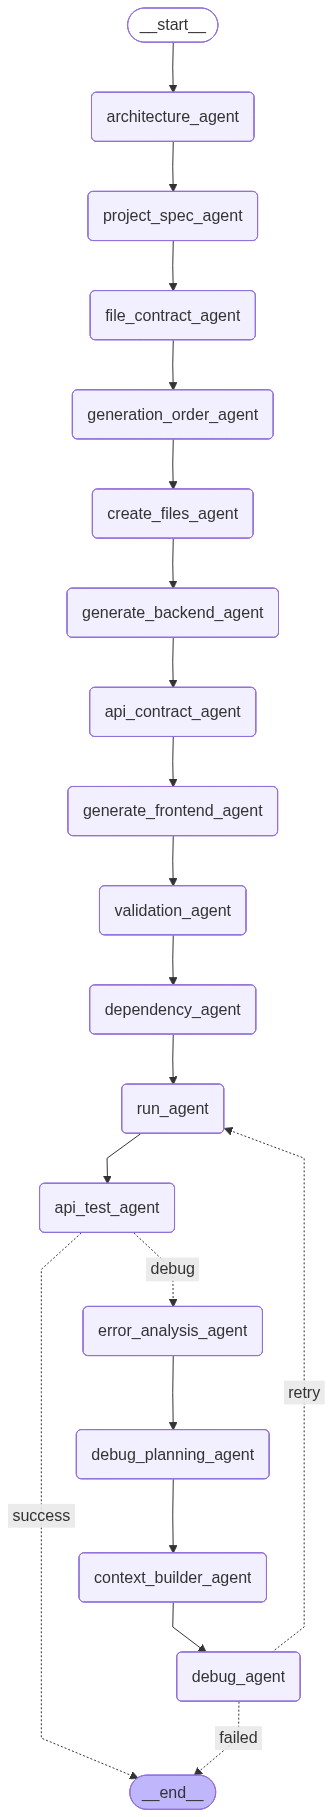

In [83]:
graph

In [84]:
from langgraph.graph import StateGraph, END

workflow = StateGraph(AgentState)

# ==========================================================
# Nodes
# ==========================================================

workflow.add_node("architecture_agent", architecture_agent)
workflow.add_node("project_spec_agent", project_spec_agent)
workflow.add_node("file_contract_agent", file_contract_agent)
workflow.add_node("generation_order_agent", generation_order_agent)
workflow.add_node("create_files_agent", create_files_agent)

workflow.add_node("generate_backend_agent", generate_backend_agent)
workflow.add_node("api_contract_agent", api_contract_agent)
workflow.add_node("generate_frontend_agent", generate_frontend_agent)

workflow.add_node("validation_agent", validation_agent)
workflow.add_node("dependency_agent", dependency_agent)

workflow.add_node("run_agent", run_agent)
workflow.add_node("api_test_agent", api_test_agent)

workflow.add_node("error_analysis_agent", error_analysis_agent)
workflow.add_node("debug_planning_agent", debug_planning_agent)
workflow.add_node("context_builder_agent", context_builder_agent)
workflow.add_node("debug_agent", debug_agent)

# ==========================================================
# Entry Point
# ==========================================================

workflow.set_entry_point("architecture_agent")

# ==========================================================
# Routers
# ==========================================================

def backend_generation_router(state):

    if (
        state["backend_current_index"]
        <
        len(state["backend_generation_order"])
    ):
        return "continue"

    return "done"


def frontend_generation_router(state):

    if (
        state["frontend_current_index"]
        <
        len(state["frontend_generation_order"])
    ):
        return "continue"

    return "done"


def api_router(state):

    if state["api_tests_passed"]:

        return "success"

    return "debug"


def debug_router(state):

    if state["api_tests_passed"]:

        return "success"

    if (
        state["retry_count"]
        >=
        state["max_retries"]
    ):

        return "failed"

    state["retry_count"] += 1

    return "retry"

# ==========================================================
# Normal Flow
# ==========================================================

workflow.add_edge(
    "architecture_agent",
    "project_spec_agent"
)

workflow.add_edge(
    "project_spec_agent",
    "file_contract_agent"
)

workflow.add_edge(
    "file_contract_agent",
    "generation_order_agent"
)

workflow.add_edge(
    "generation_order_agent",
    "create_files_agent"
)

workflow.add_edge(
    "create_files_agent",
    "generate_backend_agent"
)

# ==========================================================
# Backend Generation Loop
# ==========================================================

workflow.add_conditional_edges(

    "generate_backend_agent",

    backend_generation_router,

    {

        "continue":
            "generate_backend_agent",

        "done":
            "api_contract_agent"

    }

)

# ==========================================================
# Frontend Generation Loop
# ==========================================================

workflow.add_edge(
    "api_contract_agent",
    "generate_frontend_agent"
)

workflow.add_conditional_edges(

    "generate_frontend_agent",

    frontend_generation_router,

    {

        "continue":
            "generate_frontend_agent",

        "done":
            "validation_agent"

    }

)

# ==========================================================
# Validation Flow
# ==========================================================

workflow.add_edge(
    "validation_agent",
    "dependency_agent"
)

workflow.add_edge(
    "dependency_agent",
    "run_agent"
)

workflow.add_edge(
    "run_agent",
    "api_test_agent"
)

# ==========================================================
# API Test Router
# ==========================================================

workflow.add_conditional_edges(

    "api_test_agent",

    api_router,

    {

        "success":
            END,

        "debug":
            "error_analysis_agent"

    }

)

# ==========================================================
# Debug Flow
# ==========================================================

workflow.add_edge(
    "error_analysis_agent",
    "debug_planning_agent"
)

workflow.add_edge(
    "debug_planning_agent",
    "context_builder_agent"
)

workflow.add_edge(
    "context_builder_agent",
    "debug_agent"
)

# ==========================================================
# Debug Retry Loop
# ==========================================================

workflow.add_conditional_edges(

    "debug_agent",

    debug_router,

    {

        "retry":
            "run_agent",

        "success":
            END,

        "failed":
            END

    }

)

# ==========================================================
# Compile
# ==========================================================

graph = workflow.compile()

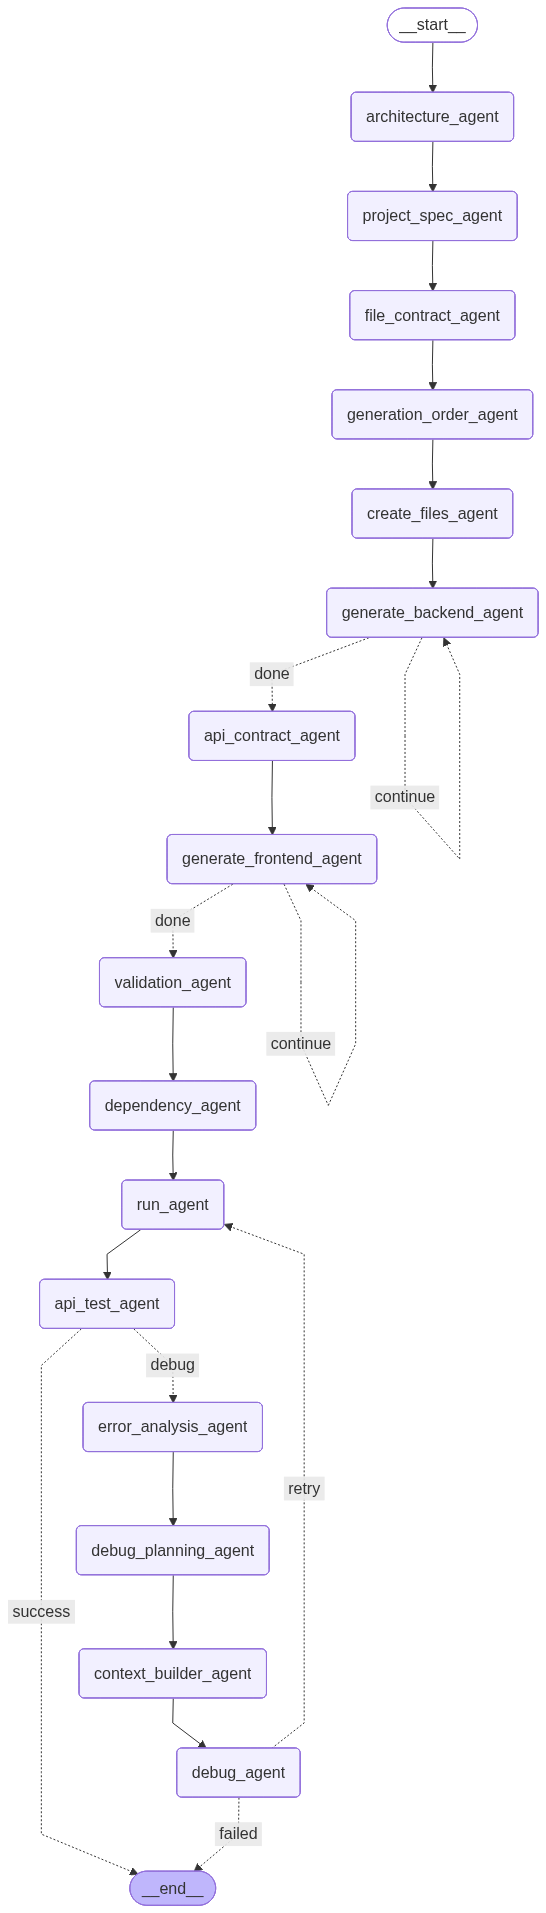

In [85]:
graph